# Demonstrate a custom reverse diffusion loop and noise scheduling


-  how the forward noise process ($q(x_t \vert{} x_0)$) and reverse denoising loop ($p_\theta(x_{t-1} \vert{} x_t)$) work mathematically using a linear variance schedule ($\beta_t$).

### Cell 1: Environment Setup & Visual Tools
Imports PyTorch and visualization libraries.

In [ ]:
# Cell 1: Environment Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on device: {device}")

Running on device: cuda


### Cell 2: Define Linear Noise Schedule & Closed-Form Constants

Implements the standard DDPM variance schedule $\beta_t \in [\beta_{\text{start}}, \beta_{\text{end}}]$, computing closed-form values for $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$.

In [ ]:
# Cell 2: Noise Schedule Setup (DDPM Constants)
class DiffusionSchedule:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02):
        self.timesteps = timesteps

        # 1. Linear Beta Schedule
        self.betas = torch.linspace(beta_start, beta_end, timesteps).to(device)

        # 2. Alpha constants
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        # 3. Calculations for Forward Process q(x_t | x_0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        # 4. Calculations for Reverse Denoising Process p(x_{t-1} | x_t)
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

# Initialize schedule with T = 1000 timesteps
schedule = DiffusionSchedule(timesteps=1000)
print("Noise Schedule initialized successfully with 1000 steps!")

Noise Schedule initialized successfully with 1000 steps!


### Cell 3: Implement Forward Diffusion Pass $q(x_t \vert{} x_0)$

Demonstrates closed-form forward sampling: adding noise directly to data $x_0$ at any arbitrary timestep $t$ without stepping sequentially.

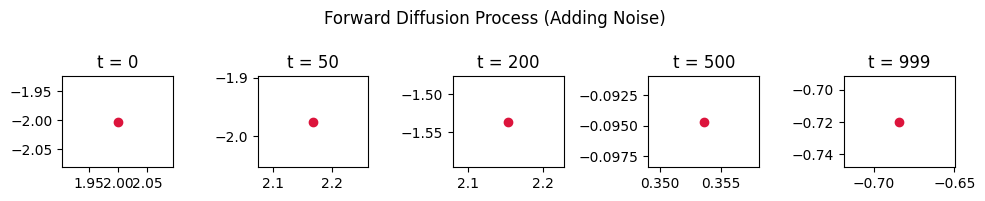

In [ ]:
# Cell 3: Closed-Form Forward Pass q(x_t | x_0)
def q_sample(x0, t, schedule, noise=None):
    """
    Directly computes x_t at timestep t:
    x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
    """
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_alpha_bar_t = schedule.sqrt_alphas_cumprod[t].view(-1, 1)
    sqrt_one_minus_alpha_bar_t = schedule.sqrt_one_minus_alphas_cumprod[t].view(-1, 1)

    return sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise

# Create synthetic 2D data point (x0)
x0 = torch.tensor([[2.0, -2.0]], device=device)

# Visualize forward corrupting process at different timesteps
timesteps_to_show = [0, 50, 200, 500, 999]
plt.figure(figsize=(10, 2))

for i, t in enumerate(timesteps_to_show):
    xt = q_sample(x0, torch.tensor([t], device=device), schedule)
    plt.subplot(1, len(timesteps_to_show), i + 1)
    plt.scatter(xt.cpu()[:, 0], xt.cpu()[:, 1], color='crimson')
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)
    plt.title(f"t = {t}")
    plt.axis('equal')

plt.suptitle("Forward Diffusion Process (Adding Noise)")
plt.tight_layout()
plt.show()

### Cell 4: Build a Score/Noise Prediction Network $\epsilon_\theta(x_t, t)$

Creates a small neural network predicting the added Gaussian noise $\epsilon$.

In [ ]:
# Cell 4: Toy Score/Noise Predictor Network
class ToyNoisePredictor(nn.Module):
    def __init__(self, dim=2, hidden_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.net = nn.Sequential(
            nn.Linear(dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, xt, t):
        # Time embedding
        t_emb = self.time_mlp(t.float().unsqueeze(-1) / 1000.0)
        h = torch.cat([xt, t_emb], dim=-1)
        return self.net(h)

# Quick training loop on a 2D cluster dataset
model = ToyNoisePredictor().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

# Target data distribution: 2D ring cluster
theta = torch.linspace(0, 2 * 3.14159, 1000)
x0_dataset = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1).to(device)

print("Training noise prediction network...")
for epoch in range(1000):
    optimizer.zero_grad()

    # 1. Random batch of x0 & timesteps t
    batch_idx = torch.randint(0, 1000, (128,))
    batch_x0 = x0_dataset[batch_idx]
    t = torch.randint(0, schedule.timesteps, (128,), device=device)

    # 2. Add noise
    noise = torch.randn_like(batch_x0)
    xt = q_sample(batch_x0, t, schedule, noise=noise)

    # 3. Predict noise and compute MSE loss
    predicted_noise = model(xt, t)
    loss = F.mse_loss(predicted_noise, noise)

    loss.backward()
    optimizer.step()

print("Network training complete!")

Training noise prediction network...
Network training complete!


### Cell 5: Reverse Diffusion Loop Sampling $p_\theta(x_{t-1} \vert{} x_t)$

Executes the iterative reverse denoising trajectory from pure noise ($x_T \sim \mathcal{N}(0, \mathbf{I})$) back to data ($x_0$).

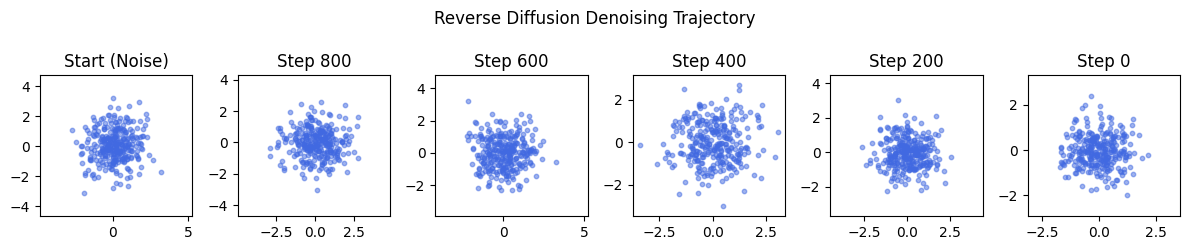

In [ ]:
# Cell 5: Explicit Reverse Denoising Sampling Loop
@torch.no_grad()
def p_sample_loop(model, schedule, shape):
    """
    Iterative Reverse Trajectory:
    x_{t-1} = 1/sqrt(alpha_t) * (x_t - (beta_t / sqrt(1 - alpha_bar_t)) * eps_theta) + sigma_t * z
    """
    model.eval()

    # 1. Start from pure Gaussian noise at t = T-1 (1000)
    x = torch.randn(shape, device=device)
    trajectory = [x.cpu()]

    # 2. Step backwards from t = T-1 to t = 0
    for t in reversed(range(0, schedule.timesteps)):
        t_tensor = torch.full((shape[0],), t, device=device, dtype=torch.long)

        # Predict noise using the neural network
        predicted_noise = model(x, t_tensor)

        # Extract scheduler coefficients
        beta_t = schedule.betas[t]
        sqrt_alpha_t = torch.sqrt(schedule.alphas[t])
        sqrt_one_minus_alpha_bar_t = schedule.sqrt_one_minus_alphas_cumprod[t]

        # Compute mean mu_theta(x_t, t)
        mean = (1.0 / sqrt_alpha_t) * (
            x - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise
        )

        # Add stochastic noise z if t > 0
        if t > 0:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(schedule.posterior_variance[t])
            x = mean + sigma_t * noise
        else:
            x = mean  # Deterministic last step

        # Store intermediate steps for visualization
        if t % 200 == 0 or t == 0:
            trajectory.append(x.cpu())

    return x, trajectory

# Run reverse sampling for 300 points
generated_points, trajectory = p_sample_loop(model, schedule, shape=(300, 2))

# 3. Plot trajectory evolution over time
fig, axes = plt.subplots(1, len(trajectory), figsize=(12, 2.5))
for i, x_t in enumerate(trajectory):
    axes[i].scatter(x_t[:, 0], x_t[:, 1], alpha=0.5, color='royalblue', s=10)
    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(-3, 3)
    axes[i].set_title(f"Step {1000 - i*200}" if i > 0 else "Start (Noise)")
    axes[i].axis('equal')

plt.suptitle("Reverse Diffusion Denoising Trajectory")
plt.tight_layout()
plt.show()

1. Forward Pass ($q$): Purely analytic (no neural network involved). We can sample $x_t$ directly at any arbitrary timestep $t$ in a single step using closed-form constants ($\bar{\alpha}_t$).

2. Reverse Pass ($p_\theta$): Sequential step-by-step loop. The model $\epsilon_\theta$ predicts the noise added at step $t$, which is subtracted to estimate the posterior mean $\boldsymbol{\mu}_\theta(x_t, t)$.

3. Sampling Complexity: Standard DDPM requires stepping through every step sequentially ($NFE = 1000$), which is why fast ODE solvers (DPM-Solver++, DDIM) or Flow Matching models are used in modern pipelines to jump steps.